# Attractors: original → September → October

Do the three revisions of the autophagy/apoptosis model keep the **same attractor landscape**? Or
does each revision add or remove whole groups of attractors? `01_network_structure_comparison`
showed what changed in the rules. This notebook shows what those changes do to the attractors.

Attractors are computed the same way as in each version's `00_analysis_boolean_core.ipynb`: the
minimal trap spaces at the leaves of the biobalm succession diagram. A node that is free in a trap
space (`*`, stored as 0.5) oscillates, or is not fixed, inside that attractor.

The revisions do not have the same nodes, so every comparison is made on what they share:

| | |
|---|---|
| **inputs** | the 6 inputs common to all three versions → 64 input combinations. October adds a 7th input, `DNA_damage`. It is held at 0 for the like-for-like comparison, and `DNA_damage = 1` is shown as a fourth landscape, *october + DNA_damage*. |
| **readouts** | nodes styled as outputs (`True_output`, `Phenomenons`) in all three GINsim files. They define the phenotype groups. |
| **core nodes** | every non-input node present in all three versions. Attractors are matched one by one on these nodes. |

Attractors are grouped at two levels:
- **class** `C…` is the exact 0 / 1 / `*` pattern of all shared readouts.
- **fate** `F…` is the pattern of `Apoptosis`, `Proliferation` and `Autop_digestion` only. It is a
  coarser grouping, and each class belongs to exactly one fate.

In [1]:
import os
import xml.etree.ElementTree as ET
import zipfile
from pathlib import Path

import biobalm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import BoundaryNorm, ListedColormap, to_rgb
from IPython.display import display
from matplotlib.patches import Patch, Rectangle

if not Path("model").exists():          # repo root
    os.chdir("../../../../")
pd.set_option("display.max_colwidth", None)
plt.rcParams["figure.dpi"] = 110

VERSIONS = {
    "original":  Path("model/autophagy/Autophagy_and_apoptosis.bnet"),
    "september": Path("model/autophagy_september26/Autophagy_and_apoptosis_Sept26.bnet"),
    "october":   Path("model/autophagy_october26/Autophagy_and_apoptosis_Sept26_2026-10-01.bnet"),
}

In [2]:
def attractors(path):
    '''One row per attractor, one column per node: 0 / 1, or 0.5 for a node free in the trap space.'''
    sd = biobalm.SuccessionDiagram.from_file(str(path))
    sd.build()
    leaves = [n for n in sd.node_ids() if sd.node_data(n).get("attractor_candidates")]
    # every attractor is a minimal trap space here; a motif-avoidant attractor would need its own handling
    assert all(sd.node_is_minimal(n) for n in leaves), f"{path}: attractor in a non-minimal trap space"
    states = pd.DataFrame([sd.node_data(n)["space"] for n in leaves], index=leaves)
    return states.reindex(columns=sd.network.variable_names()).fillna(0.5).astype(float)


def input_nodes(path):
    '''Nodes whose rule is the node itself (`X, X`).'''
    rules = (line.split("#")[0].split(",", 1) for line in path.read_text().splitlines())
    return sorted(t.strip() for t, *f in rules if f and t.strip() != "targets" and f[0].strip() == t.strip())


def ginsim_styles(path):
    '''GINsim node style per node ('Input', 'True_output', 'Phenomenons', ...).'''
    root = ET.fromstring(zipfile.ZipFile(path).read("GINsim-data/regulatoryGraph.ginml"))
    return {n.get("id"): v.get("style") or "" for n in root.iter("node") for v in n.iter("nodevisualsetting")}


ATT = {v: attractors(p) for v, p in VERSIONS.items()}
INPUTS = {v: input_nodes(p) for v, p in VERSIONS.items()}
STYLE = {v: ginsim_styles(next(p.parent.glob("*.zginml"))) for v, p in VERSIONS.items()}

## 0 — Common ground

The October landscape is split on its extra input, so that *october* has the same 64 input
combinations as the other two versions.

In [3]:
SHARED_INPUTS = sorted(set.intersection(*map(set, INPUTS.values())))
SHARED_NODES = sorted(set.intersection(*(set(a.columns) for a in ATT.values())), key=str.lower)
CORE = [n for n in SHARED_NODES if n not in SHARED_INPUTS]

FATE = ["Apoptosis", "Proliferation", "Autop_digestion"]
_readouts = set.intersection(*({n for n, s in st.items() if s in ("True_output", "Phenomenons")}
                               for st in STYLE.values()))
READOUTS = FATE + sorted(_readouts - set(FATE), key=str.lower)

# one landscape per version; a version with extra inputs is split into extra = 0 and extra = 1
LANDSCAPES = {}
for v, a in ATT.items():
    extra = sorted(set(INPUTS[v]) - set(SHARED_INPUTS))
    if not extra:
        LANDSCAPES[v] = a
        continue
    LANDSCAPES[v] = a[(a[extra] == 0).all(axis=1)]
    LANDSCAPES[f"{v} + {' + '.join(extra)}"] = a[(a[extra] == 1).all(axis=1)]
MAIN = list(VERSIONS)                     # the three like-for-like landscapes


def combo(a):
    '''Input combination of each attractor as a string of 0/1, in SHARED_INPUTS order.'''
    return a[SHARED_INPUTS].astype(int).astype(str).agg("".join, axis=1)


print("shared inputs  ", SHARED_INPUTS)
print("extra inputs   ", {v: sorted(set(i) - set(SHARED_INPUTS)) for v, i in INPUTS.items()})
print("readouts       ", READOUTS)
print(f"core nodes      {len(CORE)} (of {', '.join(f'{v} {a.shape[1]}' for v, a in ATT.items())})")

shared inputs   ['AA_Starvation', 'Glucose_starv', 'Growth_factor', 'Insuline', 'O_stress', 'TNF_R_or_DR']
extra inputs    {'original': [], 'september': [], 'october': ['DNA_damage']}
readouts        ['Apoptosis', 'Proliferation', 'Autop_digestion', 'Atphgo_form', 'Atphgo_mat', 'Cell_cycle', 'ER_stress', 'Lysosome_prod', 'Mito_overcharge', 'MOMP']
core nodes      112 (of original 119, september 119, october 125)


## 1 — Size of each landscape

In [4]:
def size(a):
    free = (a == 0.5).sum(axis=1)
    per_combo = a.groupby(combo(a)).size()
    return {"attractors": len(a),
            "input combinations": len(per_combo),
            "attractors per combination": "–".join(map(str, sorted({per_combo.min(), per_combo.max()}))),
            "multistable combinations": int((per_combo > 1).sum()),
            "fixed points": int((free == 0).sum()),
            "with free (*) nodes": int((free > 0).sum()),
            "free nodes, max": int(free.max()),
            "distinct readout patterns": a[READOUTS].drop_duplicates().shape[0]}

pd.DataFrame({L: size(a) for L, a in LANDSCAPES.items()})

,original,september,october,october + DNA_damage
attractors,128,88,64,64
input combinations,64,64,64,64
attractors per combination,2,1–2,1,1
multistable combinations,64,24,0,0
fixed points,128,6,4,0
with free (*) nodes,0,82,60,64
"free nodes, max",0,54,52,59
distinct readout patterns,3,6,5,4


## 2 — Phenotype classes: kept, added, removed

Every distinct readout pattern found in any landscape becomes a class. Classes are numbered in
order of first appearance (original → september → october → october + DNA_damage), so a class
first seen in a later revision has a higher number. The count matrix shows directly which classes
each revision keeps (non-zero in both), adds (zero before) or removes (zero after).

In [5]:
SYMBOL = {0.0: "0", 0.5: "*", 1.0: "1"}
STATE_CMAP = ListedColormap(["#3b4cc0", "#c8c8c8", "#b40426"])          # OFF / free / ON, as in 00_*
STATE_NORM = BoundaryNorm([-0.25, 0.25, 0.75, 1.25], STATE_CMAP.N)
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]


def pattern(a, cols=READOUTS):
    return a[cols].apply(lambda c: c.map(SYMBOL)).agg("".join, axis=1)


PATTERNS = {L: pattern(a) for L, a in LANDSCAPES.items()}
counts = pd.DataFrame({L: p.value_counts() for L, p in PATTERNS.items()}).fillna(0).astype(int)
first_seen = counts.ne(0).to_numpy().argmax(axis=1)
counts = counts.iloc[np.lexsort((-counts.sum(axis=1).to_numpy(), first_seen))]
CLASS = {p: f"C{i + 1}" for i, p in enumerate(counts.index)}

fate_of = lambda p: p[:len(FATE)]
FATE_ID = {f: f"F{i + 1}" for i, f in enumerate(dict.fromkeys(map(fate_of, counts.index)))}
assert len(FATE_ID) <= len(CATEGORICAL), "more fates than categorical colours"
FATE_COLOR = {fid: CATEGORICAL[i] for i, fid in enumerate(FATE_ID.values())}
FATE_NAME = {fid: ", ".join(n if s == "1" else f"{n} (free)" for n, s in zip(FATE, f) if s != "0") or "none ON"
             for f, fid in FATE_ID.items()}
CLASS_FATE = {CLASS[p]: FATE_ID[fate_of(p)] for p in counts.index}


def present_in(row):
    seen = [L for L in LANDSCAPES if row[L]]
    return "all" if len(seen) == len(LANDSCAPES) else ", ".join(seen)


catalogue = pd.DataFrame({
    "fate": [f"{CLASS_FATE[CLASS[p]]}: {FATE_NAME[CLASS_FATE[CLASS[p]]]}" for p in counts.index],
    "readouts ON": [", ".join(r for r, s in zip(READOUTS, p) if s == "1") for p in counts.index],
    "readouts free (*)": [", ".join(r for r, s in zip(READOUTS, p) if s == "*") for p in counts.index],
}, index=counts.index.map(CLASS))
catalogue = catalogue.join(counts.rename(index=CLASS))
catalogue["present in"] = counts.rename(index=CLASS).apply(present_in, axis=1)
catalogue

,fate,readouts ON,readouts free (*),original,september,october,october + DNA_damage,present in
C1,F1: Apoptosis,"Apoptosis, Cell_cycle, ER_stress, Mito_overcharge, MOMP",,112,24,0,0,"original, september"
C2,F2: Proliferation,"Proliferation, Cell_cycle",,8,6,4,0,"original, september, october"
C3,F1: Apoptosis,"Apoptosis, Cell_cycle, MOMP",,8,0,0,0,original
C4,F1: Apoptosis,"Apoptosis, Cell_cycle, ER_stress, Mito_overcharge, MOMP",Lysosome_prod,0,24,0,0,september
C5,"F3: Apoptosis, Proliferation (free)","Apoptosis, Cell_cycle, ER_stress, Mito_overcharge, MOMP",Proliferation,0,18,0,0,september
C6,"F3: Apoptosis, Proliferation (free)","Apoptosis, Cell_cycle, ER_stress, Mito_overcharge, MOMP","Proliferation, Lysosome_prod",0,12,0,0,september
C7,"F4: Apoptosis (free), Proliferation (free), Autop_digestion (free)",Cell_cycle,"Apoptosis, Proliferation, Autop_digestion, Atphgo_form, Atphgo_mat, Lysosome_prod, MOMP",0,4,4,0,"september, october"
C8,F1: Apoptosis,"Apoptosis, ER_stress, Mito_overcharge, MOMP",,0,0,32,32,"october, october + DNA_damage"
C9,F1: Apoptosis,"Apoptosis, Cell_cycle, ER_stress, Lysosome_prod, Mito_overcharge, MOMP",,0,0,16,0,october
C10,"F3: Apoptosis, Proliferation (free)","Apoptosis, ER_stress, Mito_overcharge, MOMP","Proliferation, Cell_cycle, Lysosome_prod",0,0,8,0,october


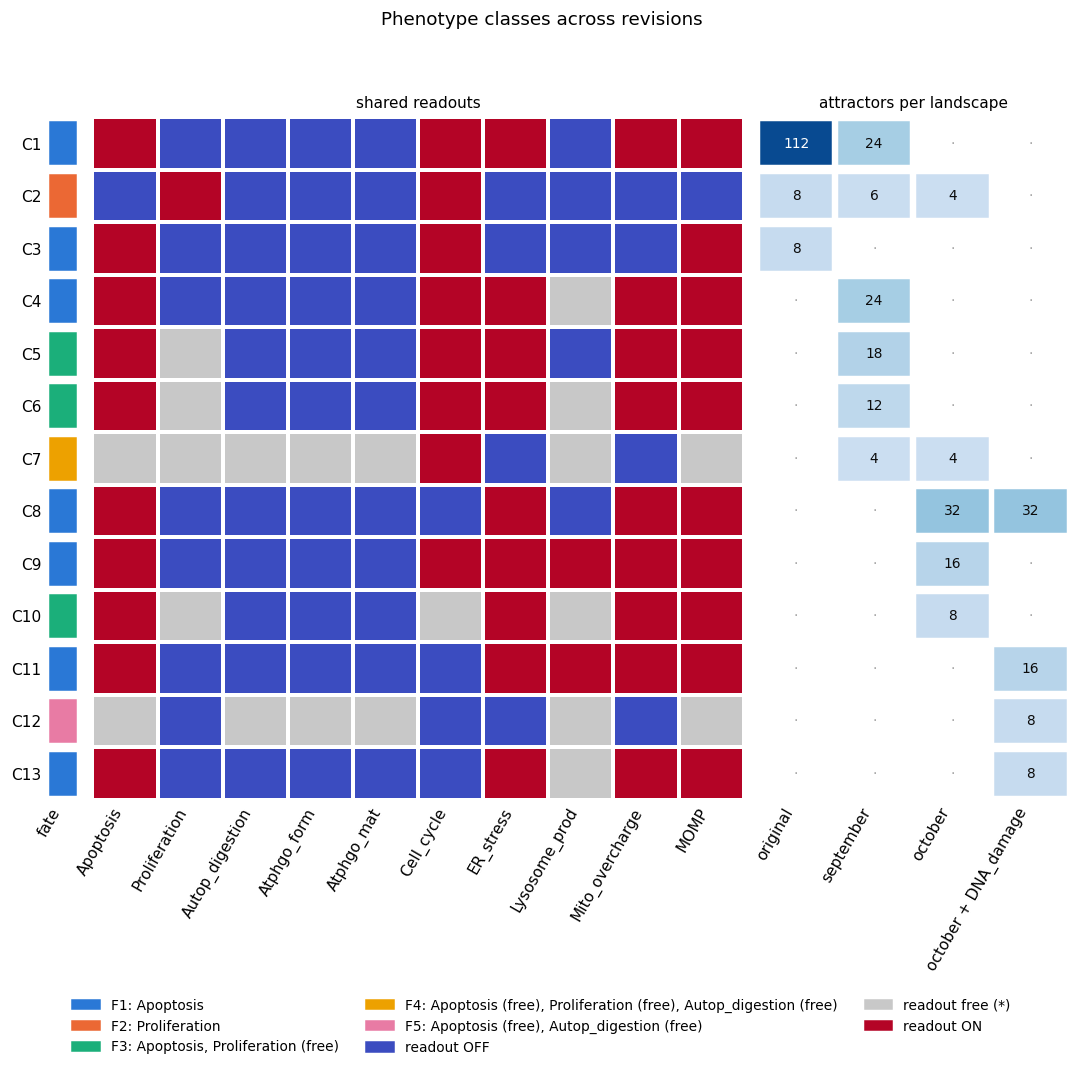

In [6]:
def ink(colour):
    '''Near-black text on light fills, white on dark ones.'''
    r, g, b = to_rgb(colour)
    return "#0b0b0b" if 0.2126 * r + 0.7152 * g + 0.0722 * b > 0.55 else "white"


def catalogue_figure():
    n, L = len(counts), list(LANDSCAPES)
    fig, (ax_f, ax_r, ax_c) = plt.subplots(
        1, 3, figsize=(12, 0.42 * n + 2.6), sharey=True,
        gridspec_kw={"width_ratios": [0.5, len(READOUTS), 1.2 * len(L)], "wspace": 0.04})
    y = np.arange(n)

    for i, c in enumerate(CLASS.values()):                     # fate chip per class
        ax_f.add_patch(Rectangle((-0.4, i - 0.4), 0.8, 0.8, color=FATE_COLOR[CLASS_FATE[c]]))
    ax_f.set_xlim(-0.5, 0.5)
    ax_f.set_xticks([0])
    ax_f.set_xticklabels(["fate"], rotation=60, ha="right")
    ax_f.set_yticks(y)
    ax_f.set_yticklabels(CLASS.values())

    values = np.array([[float({"0": 0, "*": 0.5, "1": 1}[s]) for s in p] for p in counts.index])
    ax_r.pcolormesh(np.arange(len(READOUTS) + 1) - 0.5, np.arange(n + 1) - 0.5, values,
                    cmap=STATE_CMAP, norm=STATE_NORM, edgecolors="white", linewidth=1.5)
    ax_r.set_xticks(range(len(READOUTS)))
    ax_r.set_xticklabels(READOUTS, rotation=60, ha="right")
    ax_r.set_title("shared readouts", fontsize=10)

    m = counts.to_numpy()
    cmap = plt.get_cmap("Blues")
    vmax = m.max()
    for i in range(n):
        for j in range(len(L)):
            if m[i, j]:
                fill = cmap(0.2 + 0.7 * m[i, j] / vmax)
                ax_c.add_patch(Rectangle((j - 0.45, i - 0.4), 0.9, 0.8, color=fill))
                ax_c.text(j, i, m[i, j], ha="center", va="center", fontsize=9, color=ink(fill))
            else:
                ax_c.text(j, i, "·", ha="center", va="center", fontsize=9, color="#9e9e9e")
    ax_c.set_xlim(-0.5, len(L) - 0.5)
    ax_c.set_xticks(range(len(L)))
    ax_c.set_xticklabels(L, rotation=60, ha="right")
    ax_c.set_title("attractors per landscape", fontsize=10)

    for ax in (ax_f, ax_r, ax_c):
        ax.set_ylim(n - 0.5, -0.5)
        ax.tick_params(length=0)
        for s in ax.spines.values():
            s.set_visible(False)

    handles = [Patch(color=FATE_COLOR[f], label=f"{f}: {FATE_NAME[f]}") for f in FATE_COLOR]
    handles += [Patch(color=STATE_CMAP(k), label=t) for k, t in enumerate(["readout OFF", "readout free (*)", "readout ON"])]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3, frameon=False, fontsize=9)
    fig.suptitle("Phenotype classes across revisions", y=1.0)
    plt.show()


catalogue_figure()

## 3 — What happens to each input combination

First at the level of fates: how many input combinations reach each fate, and how each
combination's fates move from original to October. Then at the level of classes.

Each input combination gets a **signature** in each landscape: the classes of its attractors
(`C3×2` means two attractors, both in class C3). The flow table counts how many of the 64
combinations follow each path from original to October. If a revision only re-labelled
phenotypes, each signature would map to one signature in the next revision. If it split or merged
attractor groups, one signature would fan out to several, or several would fan in to one.

In [7]:
def signature(classes):
    classes = sorted(classes, key=lambda c: int(c[1:]))
    return " + ".join(c if k == 1 else f"{c}×{k}" for c, k in pd.Series(classes).value_counts(sort=False).items())


COMBO = pd.DataFrame({L: PATTERNS[L].map(CLASS).groupby(combo(LANDSCAPES[L])).agg(list) for L in LANDSCAPES})
SIG = COMBO.map(signature)

FATE_SIG = COMBO.map(lambda cs: " + ".join(sorted({CLASS_FATE[c] for c in cs})))
fate_combos = pd.DataFrame({L: {f: int(COMBO[L].map(lambda cs: f in {CLASS_FATE[c] for c in cs}).sum())
                                for f in FATE_COLOR} for L in LANDSCAPES})
fate_combos.index = [f"{f}: {FATE_NAME[f]}" for f in fate_combos.index]
display(fate_combos.rename_axis("input combinations reaching each fate"))
display(FATE_SIG.groupby(MAIN).size().rename("input combinations").reset_index()
        .sort_values("input combinations", ascending=False, ignore_index=True))

flow = SIG.groupby(MAIN).size().rename("input combinations").reset_index()
flow.sort_values("input combinations", ascending=False, ignore_index=True)

,original,september,october,october + DNA_damage
input combinations reaching each fate,,,,
F1: Apoptosis,60,32,48,56
F2: Proliferation,4,4,4,0
"F3: Apoptosis, Proliferation (free)",0,24,8,0
"F4: Apoptosis (free), Proliferation (free), Autop_digestion (free)",0,4,4,0
"F5: Apoptosis (free), Autop_digestion (free)",0,0,0,8


,original,september,october,input combinations
0,F1,F1,F1,32
1,F1,F3,F1,16
2,F1,F3,F3,8
3,F1,F4,F4,4
4,F2,F2,F2,4


,original,september,october,input combinations
0,C1×2,C6,C8,8
1,C1×2,C1,C8,4
2,C1×2,C4×2,C9,4
3,C1×2,C6,C10,4
4,C1×2,C5×2,C8,4
5,C1×2,C5,C8,4
6,C1×2,C1,C9,4
7,C3×2,C7,C7,4
8,C1×2,C4×2,C8,4
9,C1×2,C4,C9,4


The same information per input combination. Rows are input combinations, with the inputs on the
left (black = ON). In each landscape column, a cell is split into one slice per attractor. The
slice is coloured by fate and labelled with its class. Rows are sorted by signature, so input
combinations that behave alike sit together. The five scenarios used across the project are
labelled on the right.

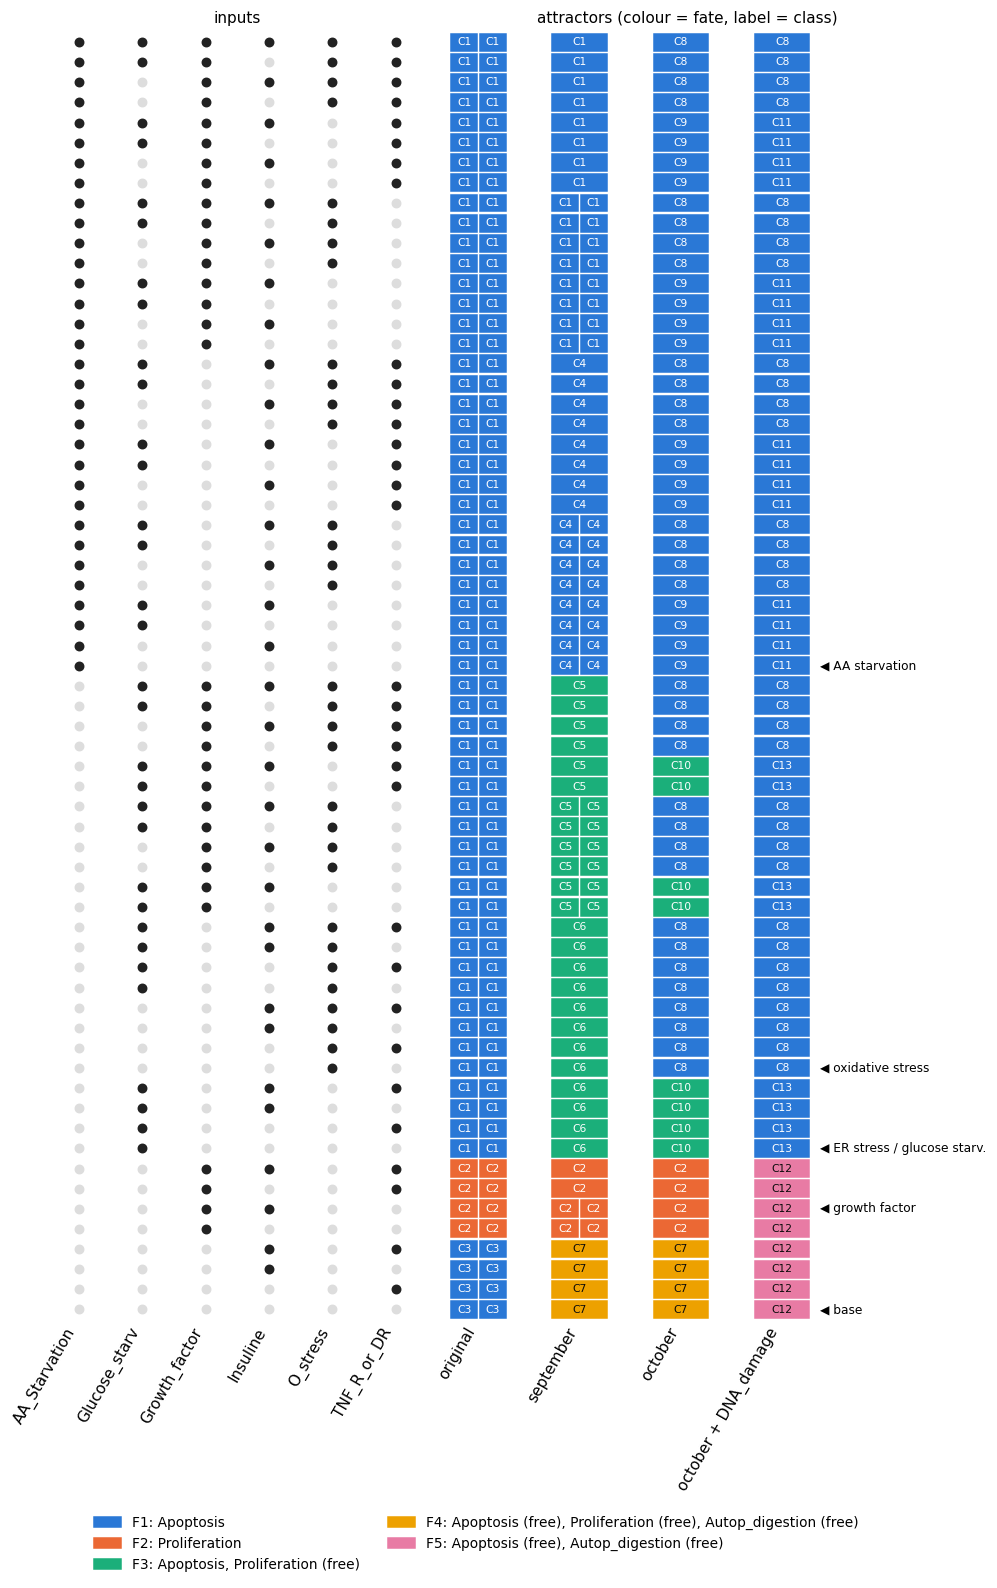

In [8]:
SCENARIOS = {"base": {}, "growth factor": {"Growth_factor": 1, "Insuline": 1},
             "AA starvation": {"AA_Starvation": 1}, "ER stress / glucose starv.": {"Glucose_starv": 1},
             "oxidative stress": {"O_stress": 1}}
SCENARIO_OF = {"".join(str(s.get(i, 0)) for i in SHARED_INPUTS): name for name, s in SCENARIOS.items()}


def combo_grid(landscapes=tuple(LANDSCAPES)):
    order = sorted(COMBO.index, key=lambda k: (
        [[int(c[1:]) for c in sorted(COMBO.at[k, L], key=lambda c: int(c[1:]))] for L in landscapes],
        [-int(b) for b in k]))
    n = len(order)
    fig, (ax_in, ax_g) = plt.subplots(
        1, 2, figsize=(4 + 1.6 * len(landscapes), 0.2 * n + 2.4), sharey=True,
        gridspec_kw={"width_ratios": [len(SHARED_INPUTS), 1.6 * len(landscapes) + 1.4], "wspace": 0.03})
    y = np.arange(n)

    bits = np.array([[int(b) for b in k] for k in order])
    for j, name in enumerate(SHARED_INPUTS):
        on = bits[:, j] == 1
        ax_in.scatter(np.full(on.sum(), j), y[on], s=30, color="#222222", zorder=3)
        ax_in.scatter(np.full((~on).sum(), j), y[~on], s=30, color="#dddddd", zorder=3)
    ax_in.set_xlim(-0.5, len(SHARED_INPUTS) - 0.5)
    ax_in.set_xticks(range(len(SHARED_INPUTS)))
    ax_in.set_xticklabels(SHARED_INPUTS, rotation=60, ha="right")
    ax_in.set_title("inputs", fontsize=10)

    for i, k in enumerate(order):
        for j, L in enumerate(landscapes):
            cs = sorted(COMBO.at[k, L], key=lambda c: int(c[1:]))
            w = 0.9 / len(cs)
            for s, c in enumerate(cs):
                x0 = j * 1.6 - 0.45 + s * w
                colour = FATE_COLOR[CLASS_FATE[c]]
                ax_g.add_patch(Rectangle((x0 + 0.02, i - 0.42), w - 0.04, 0.84, color=colour))
                ax_g.text(x0 + w / 2, i, c, ha="center", va="center", fontsize=7, color=ink(colour))
        if k in SCENARIO_OF:
            ax_g.text(1.6 * (len(landscapes) - 1) + 0.6, i, f"◀ {SCENARIO_OF[k]}", va="center", fontsize=8)
    ax_g.set_xlim(-0.6, 1.6 * len(landscapes) + 0.8)
    ax_g.set_xticks([1.6 * j for j in range(len(landscapes))])
    ax_g.set_xticklabels(landscapes, rotation=60, ha="right")
    ax_g.set_title("attractors (colour = fate, label = class)", fontsize=10)

    for ax in (ax_in, ax_g):
        ax.set_ylim(n - 0.5, -0.5)
        ax.tick_params(length=0)
        ax.set_yticks([])
        for s in ax.spines.values():
            s.set_visible(False)
    handles = [Patch(color=FATE_COLOR[f], label=f"{f}: {FATE_NAME[f]}") for f in FATE_COLOR]
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 0.0), ncol=2, frameon=False, fontsize=9)
    plt.show()


combo_grid()

### The scenarios used elsewhere in the project

In [9]:
SIG.loc[list(SCENARIO_OF)].rename(index=SCENARIO_OF)

,original,september,october,october + DNA_damage
base,C3×2,C7,C7,C12
growth factor,C2×2,C2×2,C2,C12
AA starvation,C1×2,C4×2,C9,C11
ER stress / glucose starv.,C1×2,C6,C10,C13
oxidative stress,C1×2,C6,C8,C8


## 4 — Multistability: which nodes tell the attractors of one input combination apart

When an input combination has more than one attractor, the nodes that differ between those
attractors are the switch that creates the multistability. *always* lists nodes that differ in
every multistable combination (the core of the switch). *sometimes* lists nodes that differ in
only some of them.

In [10]:
def switch(a):
    sets = [set(g.columns[g.nunique() > 1]) for _, g in a.groupby(combo(a)) if len(g) > 1]
    if not sets:
        return {"multistable combinations": 0, "always": "", "sometimes": ""}
    always = set.intersection(*sets)
    return {"multistable combinations": len(sets),
            "always": ", ".join(sorted(always, key=str.lower)),
            "sometimes": ", ".join(sorted(set.union(*sets) - always, key=str.lower))}

pd.DataFrame({L: switch(a) for L, a in LANDSCAPES.items()}).T

,multistable combinations,always,sometimes
original,64,"AKT1, NEDD4, PIK3CA, PTEN, RHOA, ROCK, YWHAB","FKBP8, GSK3A, MDM2, MTOR_C2, MYC, RHEB, TSC2"
september,24,"AKT1, NEDD4, PIK3CA, PTEN, RHOA, ROCK, YWHAB","FKBP8, GSK3A, MDM2, MTOR_C2, MYC, NFE2L2, RHEB, TSC2"
october,0,,
october + DNA_damage,0,,


## 5 — Attractor-by-attractor matching on the core nodes

Readout classes can hide changes in the rest of the network. Here every attractor of the newer
landscape is matched to the **closest attractor of the older landscape under the same input
combination**. The distance is the number of core nodes whose state (0 / 1 / `*`) differs. The match
is also made in reverse (old → closest new), which detects attractors that disappear.

- **distance 0**: the attractor is unchanged on every node the two versions share.
- **small distance**: the same attractor, shifted on a few nodes.
- **large distance**: a different attractor.

In [11]:
TRANSITIONS = list(zip(LANDSCAPES, list(LANDSCAPES)[1:]))


def match(old, new):
    '''For every attractor of `new`, its closest attractor of `old` with the same input combination.'''
    a0, a1 = LANDSCAPES[old][CORE], LANDSCAPES[new][CORE]
    k0, k1 = combo(LANDSCAPES[old]), combo(LANDSCAPES[new])
    rows = []
    for i, k in k1.items():
        cand = a0[k0 == k]
        diff = cand.ne(a1.loc[i])
        j = diff.sum(axis=1).idxmin()
        rows.append({"combination": k, new: i, old: j, "distance": int(diff.loc[j].sum()),
                     "nodes": list(diff.columns[diff.loc[j]])})
    return pd.DataFrame(rows)


MATCH = {(o, n): match(o, n) for o, n in TRANSITIONS}             # new → closest old
BACK = {(o, n): match(n, o) for o, n in TRANSITIONS}              # old → closest new


def summarise(m):
    d = m["distance"]
    return {"attractors": len(m), "identical (d = 0)": int((d == 0).sum()),
            "d ≤ 5": int((d <= 5).sum()), "median d": d.median(), "max d": d.max()}


pd.concat({
    "new → closest old": pd.DataFrame.from_dict({f"{o} → {n}": summarise(m) for (o, n), m in MATCH.items()}, orient="index"),
    "old → closest new": pd.DataFrame.from_dict({f"{o} → {n}": summarise(m) for (o, n), m in BACK.items()}, orient="index"),
}, axis=1)

new → closest old                          \
                                      attractors identical (d = 0) d ≤ 5   
original → september                          88                 0    14   
september → october                           64                 0     0   
october → october + DNA_damage                64                32    52   

                                              old → closest new  \
                               median d max d        attractors   
original → september               11.0    55               128   
september → october                10.0    18                88   
october → october + DNA_damage      2.0    61                64   

                                                                       
                               identical (d = 0) d ≤ 5 median d max d  
original → september                           0    14     17.5    63  
september → october                            0     0     13.0    30  
october → october + DNA_damage                32    52      2.0    61

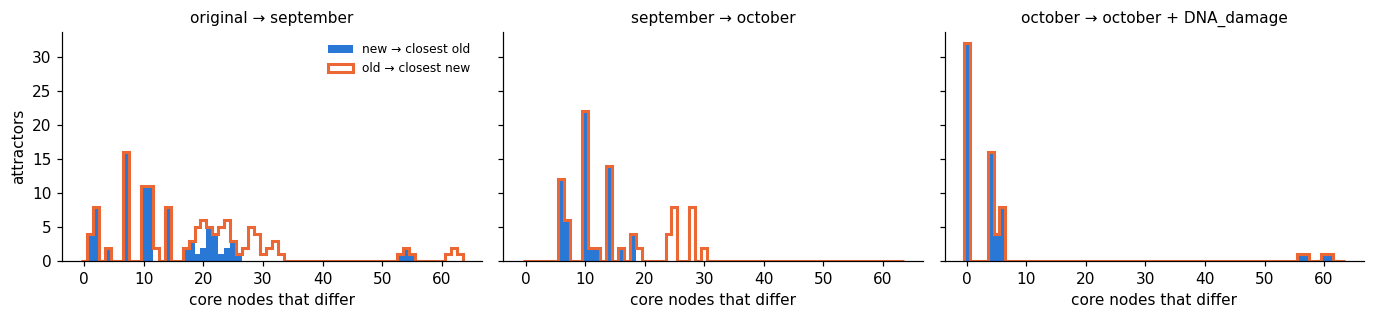

In [12]:
fig, axes = plt.subplots(1, len(TRANSITIONS), figsize=(4.2 * len(TRANSITIONS), 3), sharey=True)
dmax = max(m["distance"].max() for m in [*MATCH.values(), *BACK.values()])
bins = np.arange(-0.5, dmax + 1.5, 1)
for ax, t in zip(axes, TRANSITIONS):
    ax.hist(MATCH[t]["distance"], bins=bins, color=CATEGORICAL[0], label="new → closest old")
    ax.hist(BACK[t]["distance"], bins=bins, histtype="step", linewidth=2, color=CATEGORICAL[1],
            label="old → closest new")
    ax.set_title(f"{t[0]} → {t[1]}", fontsize=10)
    ax.set_xlabel("core nodes that differ")
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("attractors")
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

**Where the differences are.** For each transition, this is the fraction of new attractors whose
closest old attractor differs at a node. Only nodes that differ at least once are shown. A change
confined to the edited modules gives a short list. A landscape that was rebuilt gives a long one.

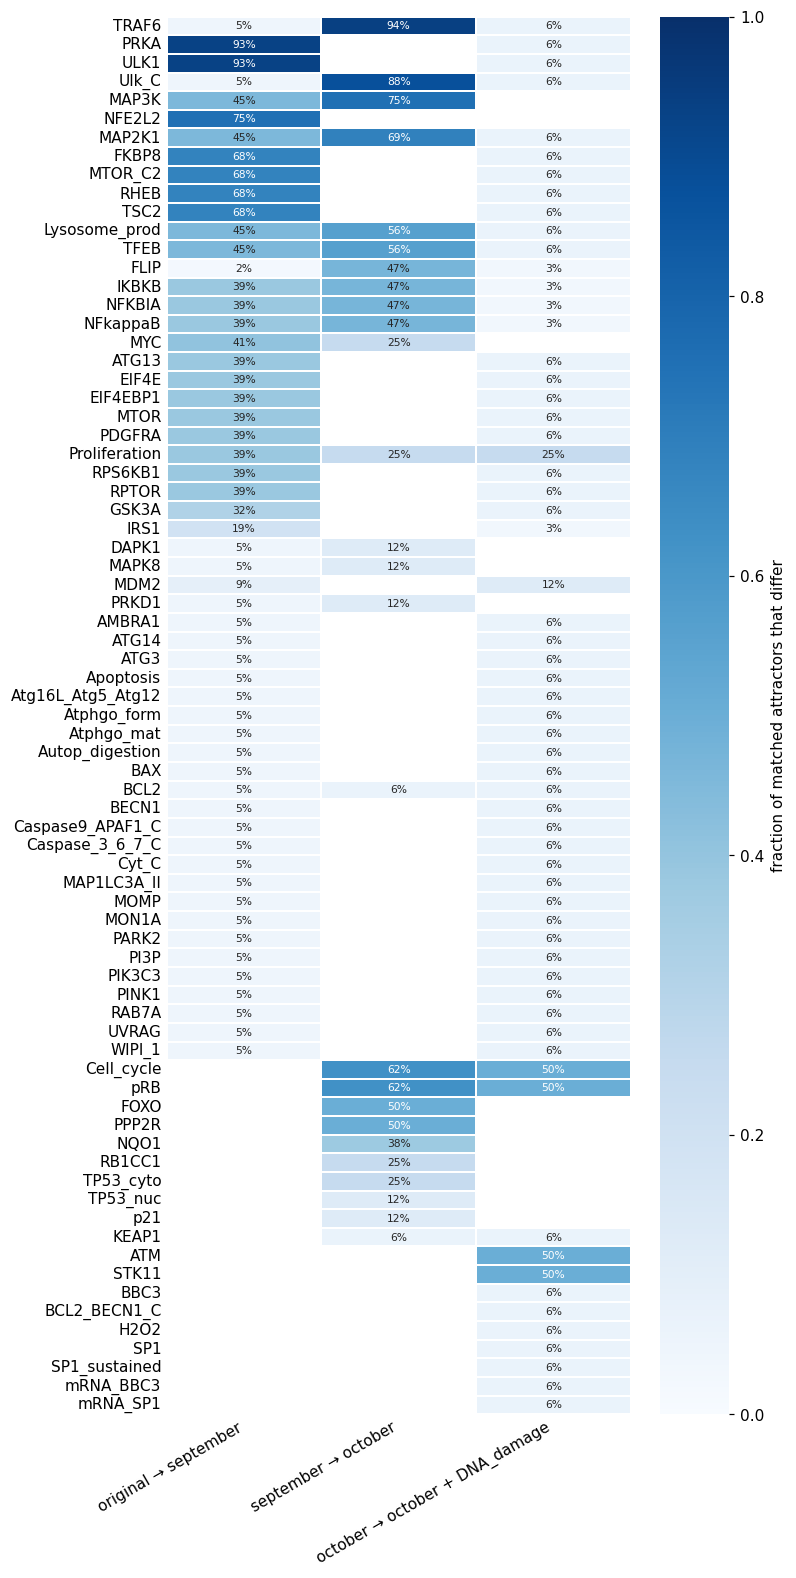

In [13]:
node_diff = pd.DataFrame({
    f"{o} → {n}": m["nodes"].explode().value_counts() / len(m) for (o, n), m in MATCH.items()
}).fillna(0)
node_diff = node_diff.iloc[np.lexsort([-node_diff.max(axis=1).to_numpy(),
                                       node_diff.ne(0).to_numpy().argmax(axis=1)])]

fig, ax = plt.subplots(figsize=(1.4 * node_diff.shape[1] + 2.6, 0.2 * len(node_diff) + 1.5))
sns.heatmap(node_diff.mask(node_diff == 0), cmap="Blues", vmin=0, vmax=1, annot=True, fmt=".0%",
            annot_kws={"fontsize": 7}, linewidths=1, linecolor="white", ax=ax,
            cbar_kws={"label": "fraction of matched attractors that differ"})
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_ylabel("")
ax.tick_params(length=0)
plt.show()

## 6 — One joint landscape

All attractors from all landscapes, on the core nodes that vary across them, clustered together
(Ward, Euclidean, same as `00_*`). If the revisions share a core structure, attractors of the same
fate from different revisions cluster together. If a revision adds a group of attractors, that
group forms its own branch, with only one revision in its version track.

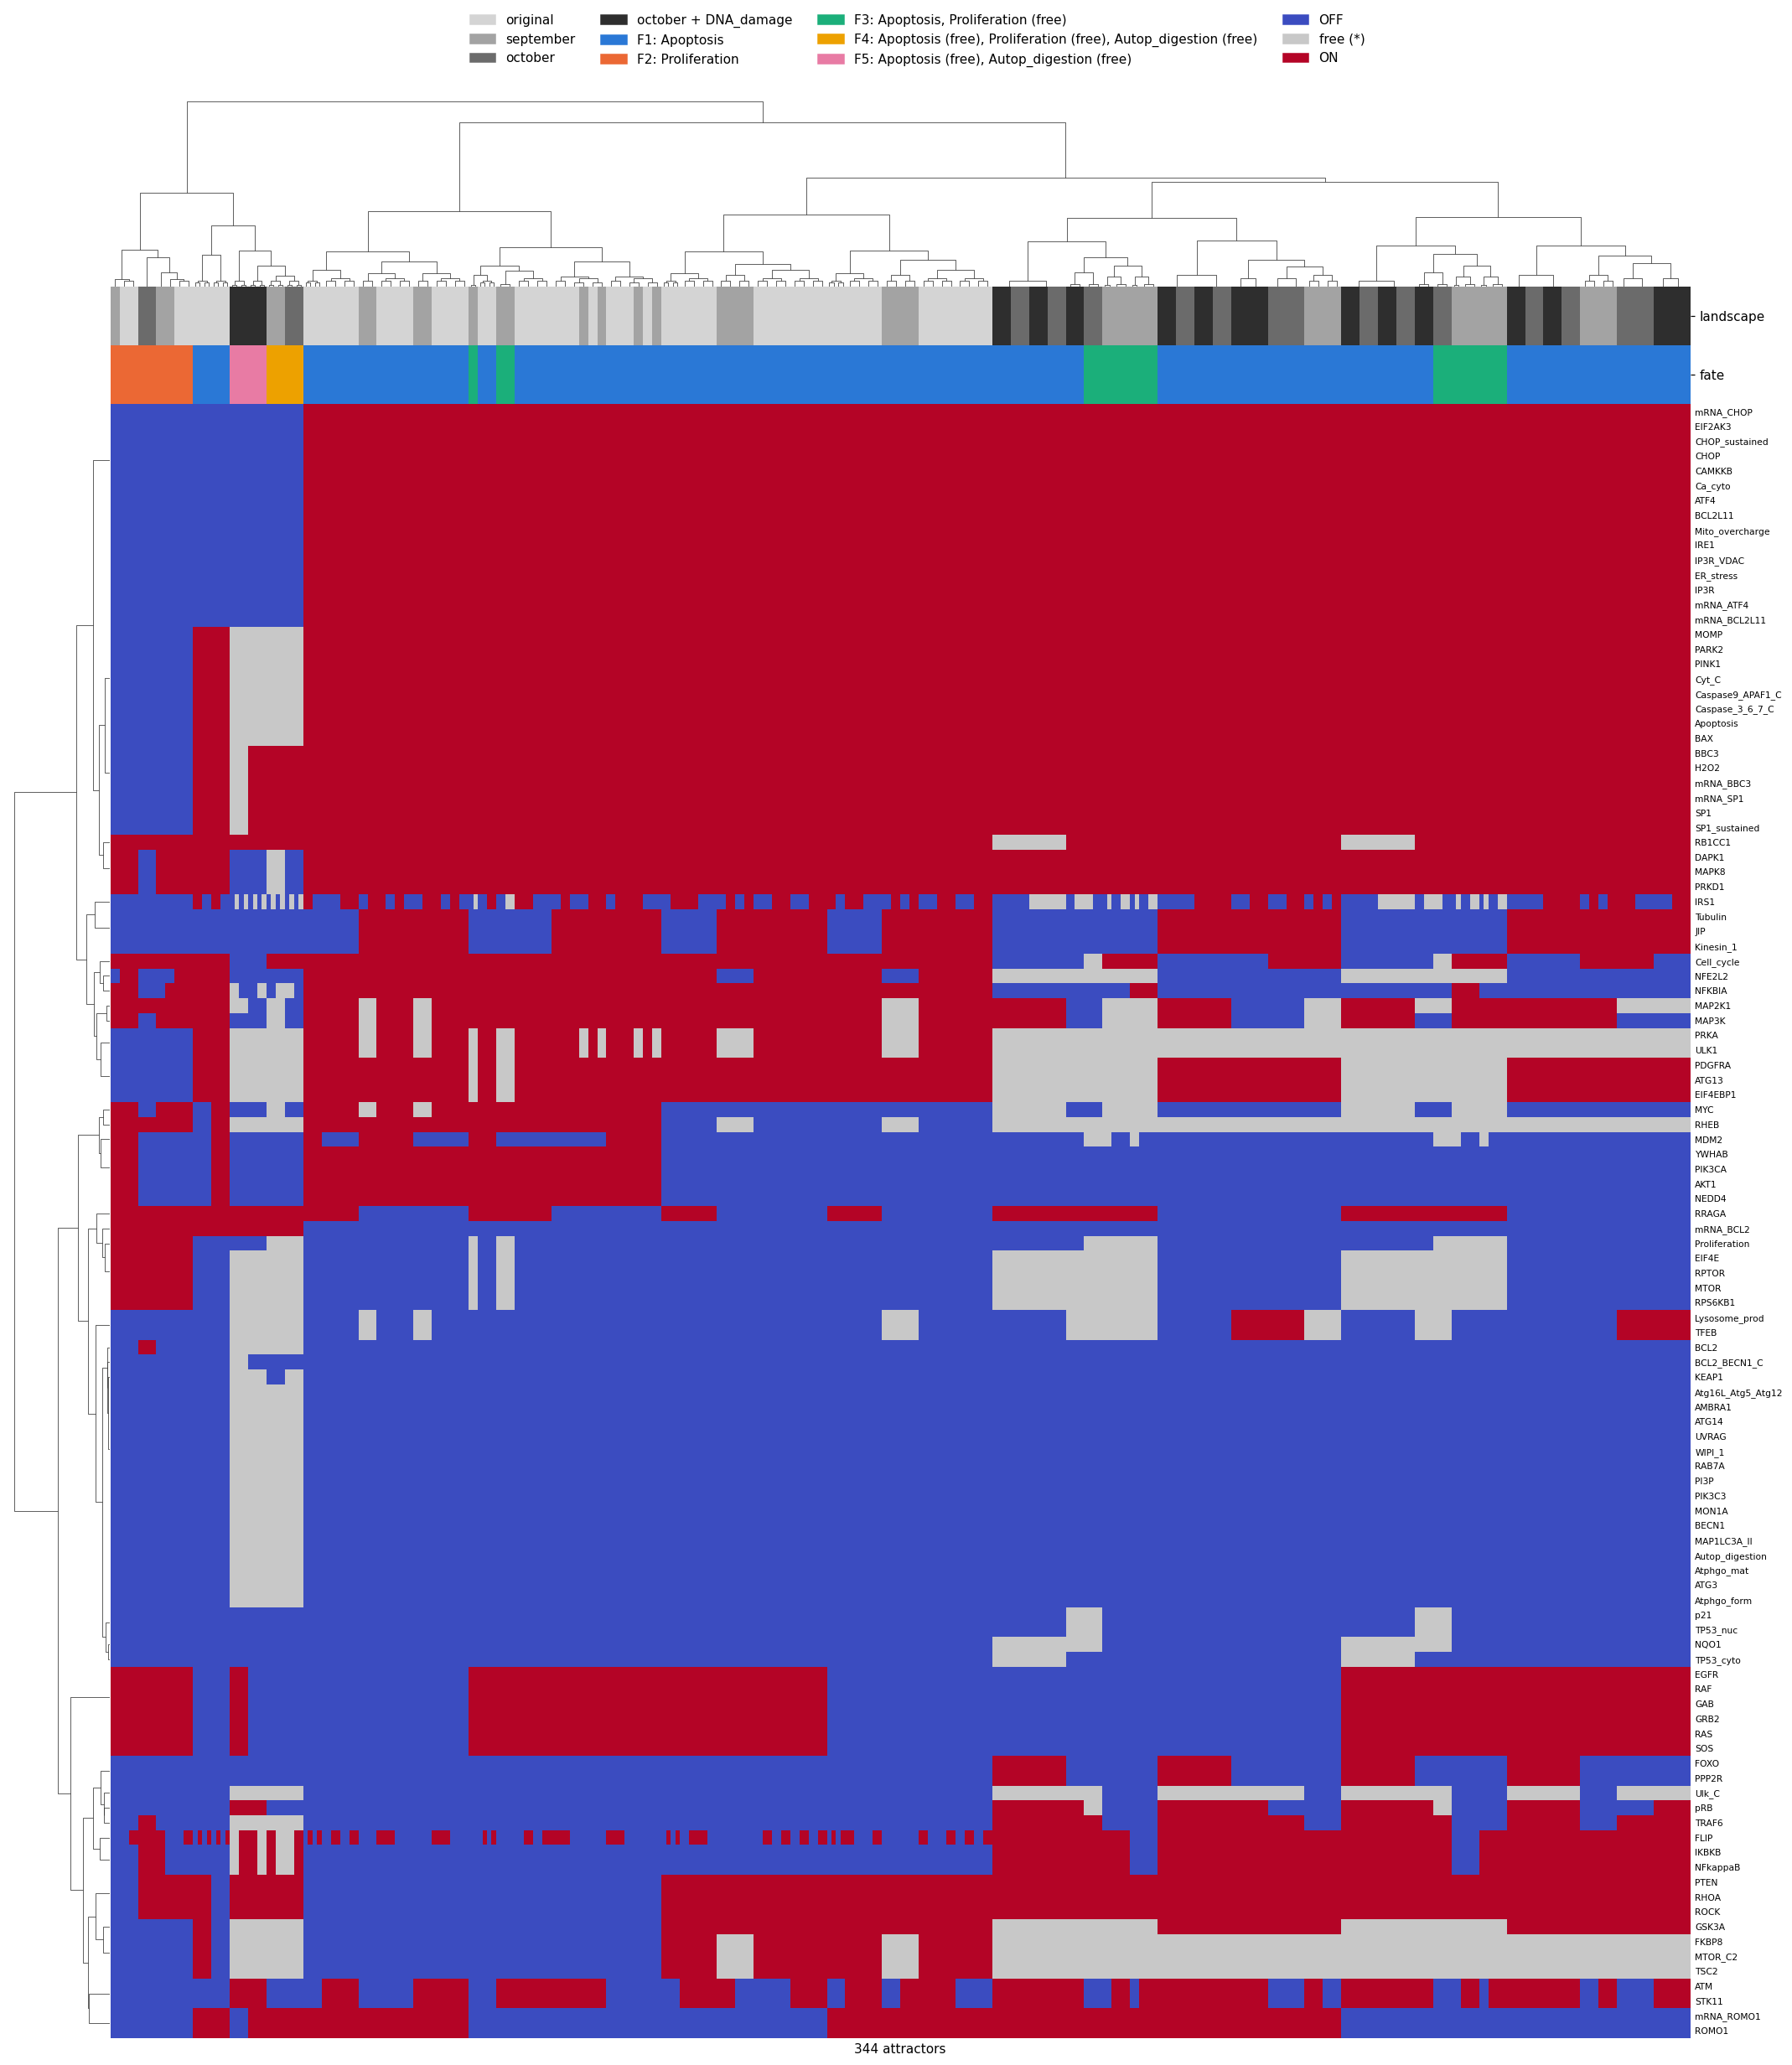

In [14]:
joint = pd.concat({L: a[CORE] for L, a in LANDSCAPES.items()}, names=["landscape", "attractor"])
joint = joint.loc[:, joint.nunique() > 1]
fates = pd.concat({L: PATTERNS[L].map(CLASS).map(CLASS_FATE) for L in LANDSCAPES})

VERSION_GREY = dict(zip(LANDSCAPES, ["#d4d4d4", "#a3a3a3", "#6b6b6b", "#2e2e2e"]))
tracks = pd.DataFrame({"landscape": joint.index.get_level_values(0).map(VERSION_GREY),
                       "fate": fates.reindex(joint.index).map(FATE_COLOR)}, index=joint.index)

g = sns.clustermap(joint.T, method="ward", metric="euclidean", cmap=STATE_CMAP, vmin=0, vmax=1, col_colors=tracks,
                   linewidths=0, figsize=(20, 0.16 * joint.shape[1] + 4), yticklabels=True, xticklabels=False,
                   dendrogram_ratio=(0.06, 0.1), cbar_pos=None)
g.ax_heatmap.tick_params(axis="y", labelsize=7, length=0)
g.ax_heatmap.set_xlabel(f"{len(joint)} attractors")
handles = ([Patch(color=c, label=L) for L, c in VERSION_GREY.items()]
           + [Patch(color=FATE_COLOR[f], label=f"{f}: {FATE_NAME[f]}") for f in FATE_COLOR]
           + [Patch(color=c, label=t) for c, t in zip(STATE_CMAP.colors, ["OFF", "free (*)", "ON"])])
g.fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=4, frameon=False, fontsize=10)
plt.show()

## 7 — October only: the new input and the new nodes

October adds the input `DNA_damage` and nodes that the other versions do not have, including the
`Senescence` readout. The table gives the state of each October-only node (number of attractors
OFF / free / ON) with `DNA_damage` OFF and ON. The crosstab shows how each input combination's
signature changes when `DNA_damage` is switched on.

In [15]:
oct_only = [n for n in ATT[MAIN[-1]].columns if n not in SHARED_NODES]
extra = [L for L in LANDSCAPES if L not in MAIN]
state_name = {0.0: "OFF", 0.5: "free", 1.0: "ON"}
pd.concat({L: LANDSCAPES[L][oct_only].apply(lambda c: c.map(state_name).value_counts())
              .reindex(["OFF", "free", "ON"]).fillna(0).astype(int).T
           for L in [MAIN[-1], *extra]}, axis=1)

october          october + DNA_damage         
                        OFF free  ON                  OFF free  ON
Autophagy                60    4   0                   56    8   0
Autophagy_sustained      60    4   0                   56    8   0
CDKN2A                   32    0  32                    0    0  64
DNA_damage               64    0   0                    0    0  64
SQSTM1                    0    4  60                    0    8  56
Senescence               24    8  32                    0    0  64
p21_sustained            56    8   0                   56    8   0

In [16]:
by_class = lambda idx: idx.map(lambda s: [int(c[1:].split("×")[0]) for c in s.split(" + ")])
pd.crosstab(SIG[MAIN[-1]], [SIG[L] for L in extra]).sort_index(key=by_class).sort_index(axis=1, key=by_class)

october + DNA_damage,C8,C11,C12,C13
october,,,,
C2,0,0,4,0
C7,0,0,4,0
C8,32,0,0,0
C9,0,16,0,0
C10,0,0,0,8


## Summary

**Same core at the fate level.** No fate of the original model is lost. The 4 input combinations
that proliferate in the original (`Growth_factor` ON, no stress; F2) still proliferate in September and
October. Of the 60 combinations that are apoptotic in the original (F1), 32 stay purely apoptotic in
all three versions. The other 28 change fate in at least one later version (see below). No input
combination moves between proliferation and apoptosis.

**What September adds.** Two new fates, both with oscillating (`*`) readouts:
- **F3**, apoptosis with Proliferation free, in 24 combinations.
- **F4**, Apoptosis, Proliferation and Autop_digestion all free, in the 4 combinations with no stress
  and no growth factor, including the *base* scenario. In the original these 4 combinations sit in class C3, the only
  apoptotic class without ER stress. C3 does not exist after the original.

**What October keeps, narrows and adds.**
- It keeps F3 and F4. F3 shrinks from 24 combinations to 8: 16 combinations go back to pure apoptosis.
- With `DNA_damage` held at 0, one input decides the class, in priority order. `O_stress` gives
  C8 (32 combinations). Otherwise `AA_Starvation` gives C9, which adds Lysosome_prod ON (16).
  Otherwise `Glucose_starv` gives C10, F3 (8). Otherwise `Growth_factor` decides between
  proliferation C2 and the oscillating C7 (4 + 4).
- In the apoptotic classes, the readouts below the fate level shift. C8 has `Cell_cycle` OFF, while
  every apoptotic attractor of the original has it ON.
- `DNA_damage = 1` removes proliferation entirely (F2 in 0 combinations). The 8 combinations that were F2 or
  F4 move to a new fate, **F5**: Apoptosis and Autop_digestion free, Proliferation OFF.
  `Senescence` is ON in all 64 of those attractors. 32 of the 64 attractors (all the
  O_stress ones) are identical with and without DNA damage.

**What the revisions remove: multistability.** In the original, every input combination has two
fixed points. They always differ in the PTEN–PIK3CA–AKT1–NEDD4–RHOA–ROCK–YWHAB module, and sometimes
on MTOR-axis nodes. Both always have the same readout class, so the switch is invisible in the
phenotype. September keeps it in 24 combinations. October has exactly one attractor per combination.
Fixed points also mostly disappear (128/128 → 6/88 → 4/64). From September on, PRKA and ULK1 are free
in most attractors. That fits the ULK1 ⊣ PRKA negative feedback that September adds
(`01_network_structure_comparison`).

**Below the readouts, no attractor is unchanged.** No attractor is identical on the 112 core nodes
from one version to the next.
- **September → October** is a shift, not a rebuild. Every October attractor is 6–18 core
  nodes (median 10) from its closest September attractor. The differences sit in the edited modules:
  TRAF6, Ulk_C, MAP3K/MAP2K1, Cell_cycle/pRB, Lysosome_prod/TFEB and FOXO/PPP2R.
- **Original → September** also has a median distance of 11. The outliers, at more than 40 nodes,
  are the 4 combinations that become the fully oscillating F4. Most of the rest comes from
  PRKA/ULK1, NFE2L2 and the MTOR_C2/RHEB/TSC2/FKBP8 axis.

**In short:** the apoptosis-versus-proliferation partition of the input space is preserved. September
adds two groups of oscillating attractors. October keeps both groups, shrinks the larger one,
removes all multistability, and with `DNA_damage` adds a fifth, senescent group that has no
proliferation.